You will use the Insurance Charges Dataset (from Kaggle)2
. This dataset includes information
about insurance charges and various features that might influence these charges, such as age,
sex, BMI, number of children, smoker status, and region.

1- Process the data


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Step 1.1: Load the dataset
load the insurance dataset from the kaggle and look at the data.

In [3]:
df = pd.read_csv("insurance.csv")
df.head()

,index,age,sex,bmi,children,smoker,region,charges
0,0,19,female,27.900,0,yes,southwest,16884.92400
1,1,18,male,33.770,1,no,southeast,1725.55230
2,2,28,male,33.000,3,no,southeast,4449.46200
3,3,33,male,22.705,0,no,northwest,21984.47061
4,4,32,male,28.880,0,no,northwest,3866.85520


The dataset contains information about people and their medical insurance charges
The column charges is the value that is asked to predict.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   index     1338 non-null   int64  
 1   age       1338 non-null   int64  
 2   sex       1338 non-null   str    
 3   bmi       1338 non-null   float64
 4   children  1338 non-null   int64  
 5   smoker    1338 non-null   str    
 6   region    1338 non-null   str    
 7   charges   1338 non-null   float64
dtypes: float64(2), int64(3), str(3)
memory usage: 83.8 KB


Now we can check if the data has any null values (this is also very common practice also occurs in Data Visulization and Analytics.)

In [5]:
df.isnull().sum()

index       0
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Step 1.2: Preprocess the data.
changing the words into numbers.

In [6]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

df.head()

,index,age,sex,bmi,children,smoker,region,charges
0,0,19,1,27.900,0,1,southwest,16884.92400
1,1,18,0,33.770,1,0,southeast,1725.55230
2,2,28,0,33.000,3,0,southeast,4449.46200
3,3,33,0,22.705,0,0,northwest,21984.47061
4,4,32,0,28.880,0,0,northwest,3866.85520


The region column has more than two categories,
so we use one-hot encoding to convert each region into separate columns.

In [7]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)
df.head()

,index,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,0,19,1,27.900,0,1,16884.92400,False,False,True
1,1,18,0,33.770,1,0,1725.55230,False,True,False
2,2,28,0,33.000,3,0,4449.46200,False,True,False
3,3,33,0,22.705,0,0,21984.47061,True,False,False
4,4,32,0,28.880,0,0,3866.85520,True,False,False


now, instead of one region column; we got 2, so we can make them zeroes and ones.

Step 1.3: Split features and target.
The input features are used to predict the target variable, thats charges.

In [8]:
X = df.drop('charges', axis=1).astype(float).values
y = df['charges'].astype(float).values

print(X.shape)
print(y.shape)
print(X.dtype)

(1338, 9)
(1338,)
float64


x is the info that is used to make predictions.
y is the answer that is desired to predict.

Step 1.4: Feature scaling
We scale the features so that large values do not overpower small values during gradient descent.

In [9]:
split_index = int(0.8 * len(X))

X_train = X[:split_index]
y_train = y[:split_index]

X_test = X[split_index:]
y_test = y[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1070
Testing samples: 268


Step 1.5: Add bias term
We add a column of ones to help the model learn the intercept.

In [11]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

std[std == 0] = 1

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print("Any NaN in X_train?", np.isnan(X_train).any())
print("Any NaN in X_test?", np.isnan(X_test).any())

Any NaN in X_train? False
Any NaN in X_test? False


Step 1.6: Train-test split
80% of the data is for training and the rest is for testing.

In [12]:
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

print(X_train[:5])
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

[[ 1.         -1.73043282 -1.45390122  1.02077653 -0.47403991 -0.90286618
   1.99417757 -0.55791981 -0.6155209   1.76504522]
 [ 1.         -1.72719534 -1.52464584 -0.97964634  0.4911621  -0.06353793
  -0.50145986 -0.55791981  1.6246402  -0.56655772]
 [ 1.         -1.72395787 -0.81719959 -0.97964634  0.36455128  1.61511857
  -0.50145986 -0.55791981  1.6246402  -0.56655772]
 [ 1.         -1.72072039 -0.46347647 -0.97964634 -1.32825191 -0.90286618
  -0.50145986  1.79237229 -0.6155209  -0.56655772]
 [ 1.         -1.71748291 -0.53422109 -0.97964634 -0.31289886 -0.90286618
  -0.50145986  1.79237229 -0.6155209  -0.56655772]]
X_train shape: (1070, 10)
X_test shape: (268, 10)


Preprocessing Summary
In this step, the dataset was loaded and cleaned.  
Categorical columns were converted into numerical values, features were scaled, and the dataset was split into training and testing sets.  
The data is now ready for implementing linear regression.

STEP 2: BUILD LINEAR REGRESSION FROM SCRATCH

Step: 2.1:
Implement Linear Regression from scratch
Gradient descent is used to learn the model parameters.

In [13]:
#no of features
n_features = X_train.shape[1]

weights = np.zeros(n_features)

print("Number of weights:", len(weights))
print(weights)

Number of weights: 10
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Prediction Function
The prediction is computed as the dot product between the input features and the weights.

In [14]:
def predict(X, weights):
    return np.dot(X, weights)

MSE
The Mean Squared Error measures how far the predictions are from the true values.

In [15]:
def compute_mse(y_true, y_pred):
    n = len(y_true)
    return np.sum((y_true - y_pred) ** 2) / n

Gradient Descent,

Gradient descent updates the weights step by step to reduce the error.

In [16]:
def gradient_descent(X, y, weights, learning_rate, epochs):
    n = len(y)
    mse_history = []

    for epoch in range(epochs):

        y_pred = predict(X, weights)
        
        error = y_pred - y

        gradient = (2 / n) * np.dot(X.T, error)

        weights = weights - learning_rate * gradient

        mse = compute_mse(y, y_pred)
        mse_history.append(mse)

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, MSE: {mse:.2f}")

    return weights, mse_history

        # Step 1: make predictions
        # Step 2: calculate error
        # Step 3: calculate gradient
        # Step 4: update weights
        # Step 5: compute MSE for tracking
        # Output: Print progress every 100 epochs

In [17]:
learning_rate = 0.01
epochs = 1000

weights = np.zeros(X_train.shape[1])

trained_weights, mse_history = gradient_descent(
    X_train, y_train, weights, learning_rate, epochs
)

print("Final weights:")
print(trained_weights)

Epoch 0, MSE: 319290318.64
Epoch 100, MSE: 41513157.34
Epoch 200, MSE: 36490017.18
Epoch 300, MSE: 36379093.56
Epoch 400, MSE: 36372922.93
Epoch 500, MSE: 36371719.30
Epoch 600, MSE: 36371396.40
Epoch 700, MSE: 36371306.87
Epoch 800, MSE: 36371281.97
Epoch 900, MSE: 36371275.04
Final weights:
[13214.12579096   -34.30004813  3668.42869251   125.85264158
  2062.2993205    523.48429478  9477.30298038  -199.85530068
  -499.14734564  -533.38202112]


Step 2.2: Visualize training error
We plot the MSE over time to observe whether gradient descent is converging.

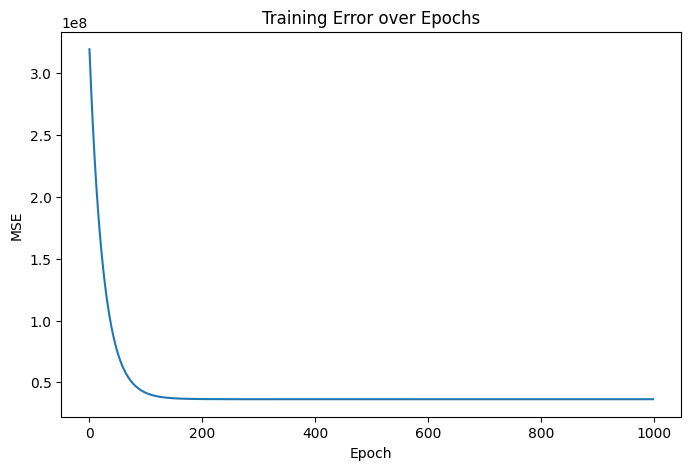

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(mse_history)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training Error over Epochs")
plt.show()

Interpretation,

If the MSE decreases as the epochs increase, then gradient descent is successfully learning better weights.

In [19]:
train_predictions = predict(X_train, trained_weights)
test_predictions = predict(X_test, trained_weights)

train_mse = compute_mse(y_train, train_predictions)
test_mse = compute_mse(y_test, test_predictions)

print("Training MSE:", train_mse)
print("Testing MSE:", test_mse)

Training MSE: 36371273.108489156
Testing MSE: 37238142.47525991


Step 2.3: Evaluation

The model was evaluated using Mean Squared Error (MSE) on both the training and testing datasets.  
A lower MSE indicates better predictive performance.

STEP 3: LINEAR REGRESSION USING SCIKIT-LEARN

In this step, we implement linear regression using the scikit-learn library and compare the results with our custom implementation.

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
sk_train_pred = model.predict(X_train)
sk_test_pred = model.predict(X_test)

In [24]:
sk_train_mse = compute_mse(y_train, sk_train_pred)
sk_test_mse = compute_mse(y_test, sk_test_pred)

print("Sklearn Training MSE:", sk_train_mse)
print("Sklearn Testing MSE:", sk_test_mse)

Sklearn Training MSE: 36371272.36478045
Sklearn Testing MSE: 37238748.06322714


STEP 4: COMPARISON OF THE RESULTS

The mse obtained from the custom implementation and the scikit learn model are being compared

The results are pretty similiar as both methods aim to minimize the same error function.  
scikit learn may achieve slightly better performance because it uses an optimized and exact mathematical solution.

This comparison validates that is correct